In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from support_assistant.data import load_tickets


ROOT = Path.cwd().parents[2]
FIGURES = ROOT / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

df = load_tickets(ROOT / "data" / "raw" / "tickets_5000.csv")
df.shape

(5000, 7)

In [2]:
weekly = df.set_index("created_at").resample("W").size()
weekly

created_at
2026-07-05    258
2026-07-12    409
2026-07-19    371
2026-07-26    352
2026-08-02    369
2026-08-09    372
2026-08-16    352
2026-08-23    379
2026-08-30    388
2026-09-06    370
2026-09-13    406
2026-09-20    393
2026-09-27    409
2026-10-04    172
Freq: W-SUN, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

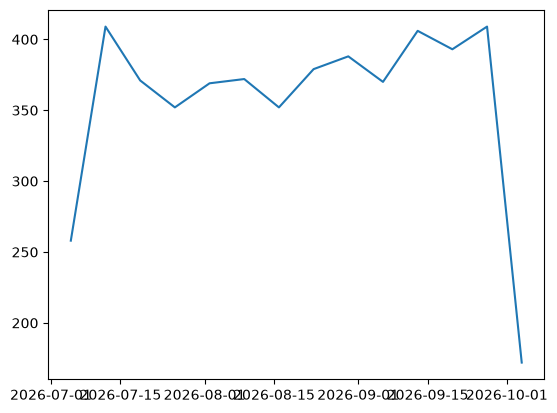

In [5]:
fig, ax = plt.subplots()
ax.plot(weekly.index,weekly.values)
plt.show


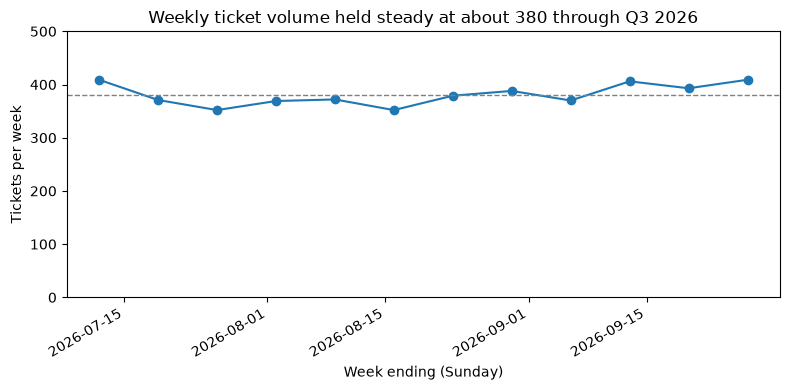

12 full weeks; min 352 max 409 mean 380.8


In [9]:
full = weekly.iloc[1:-1]  # the first and last weeks are partial: leave them out

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(full.index, full.values, marker="o")
ax.axhline(full.mean(), linestyle="--", linewidth=1, color="grey")
ax.set_ylim(0, 500)
ax.set_title("Weekly ticket volume held steady at about 380 through Q3 2026")
ax.set_xlabel("Week ending (Sunday)")
ax.set_ylabel("Tickets per week")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(FIGURES / "weekly_volume.png", dpi=150)
plt.show()
print(len(full), "full weeks; min", full.min(), "max", full.max(), "mean", round(full.mean(), 1))

In [10]:
def category_shares(df):
    """share of tickets in each category, larger first """

    return df["category"].value_counts(normalize=True)

shares = category_shares(df)
shares.round(3)

category
billing            0.309
login              0.251
bug                0.192
shipping           0.147
feature_request    0.101
Name: proportion, dtype: float64

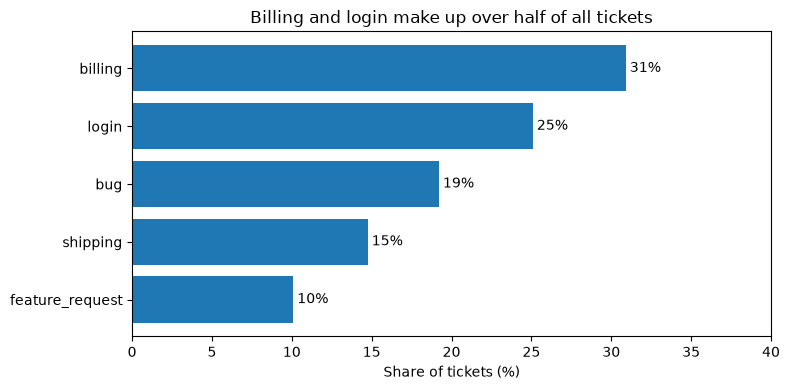

billing + login: 0.56


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(shares.index, shares.values * 100)
ax.invert_yaxis()
ax.bar_label(bars, fmt="%.0f%%", padding=3)
ax.set_xlim(0, 40)
ax.set_title("Billing and login make up over half of all tickets")
ax.set_xlabel("Share of tickets (%)")
fig.tight_layout()
fig.savefig(FIGURES / "category_shares.png", dpi=150)
plt.show()
print("billing + login:", round(shares["billing"] + shares["login"], 2))